# NumPy Hands-on Lab: From Arrays to Image Analysis

## Student Practice Notebook

**Name:** D.Yashwanth             
**Register Number:** AP24110011685  
**Date:** 07-08-2026

## Learning Objectives

After completing this lab, you will be able to:

- Create and manipulate NumPy arrays
- Understand array properties and dimensions
- Perform indexing and slicing
- Apply mathematical operations
- Understand and explain broadcasting
- Analyze images using NumPy arrays
- Perform basic image transformations
- Explain *why* NumPy is used in real ML/Data Science pipelines, not just *how*

### How to use this notebook
- **Demonstration** cells: run them, read the output, understand it.
- **Practice** cells: write your own code — don't copy the demo verbatim.
- **Predict-then-run**: before running some cells, you'll be asked to *predict* the output first. Write your prediction in the markdown cell, then run and compare.
- **Reflection**: short written answers, in your own words.


## Part 1: Introduction to NumPy

NumPy (Numerical Python) is a Python library used for efficient numerical computation.

**Why not just use Python lists?** Python lists store objects with overhead per element and loop in pure Python. NumPy arrays store raw numbers in contiguous memory and use compiled C code for operations — this is called **vectorization**. That's why NumPy is used everywhere in:

- Data Science (pandas is built on NumPy)
- Machine Learning (feeding data into models as arrays/tensors)
- Image Processing (an image *is* a NumPy array)
- Scientific Computing

Let's actually *see* the speed difference before we take it on faith.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy is ready!")


NumPy is ready!


### Demonstration: Loops vs. Vectorization (the "why" behind NumPy)

Below we add 1 to a million numbers two ways: a plain Python loop, and a NumPy array operation.
Run this cell and look at the timing output.


In [4]:
import time

n = 1_000_000
python_list = list(range(n))
numpy_array = np.arange(n)

start = time.time()
result_list = [x + 1 for x in python_list]
loop_time = time.time() - start

start = time.time()
result_array = numpy_array + 1
vector_time = time.time() - start

print(f"Python loop time : {loop_time:.5f} seconds")
print(f"NumPy vector time: {vector_time:.5f} seconds")
print(f"NumPy was about {loop_time/vector_time:.0f}x faster")


Python loop time : 0.09447 seconds
NumPy vector time: 0.00481 seconds
NumPy was about 20x faster


**Reflection (write your answer):** Based on the timing above, in your own words, why is NumPy faster than a Python loop for this kind of operation?

*Your answer:* for larger value of n, numpy creates the array faster beacuse it operates directly in optimized C code and bypasses python's object overhead.


## Part 2: Creating NumPy Arrays

### Demonstration

In [ ]:
arr = np.array([10,20,30,40,50])
arr

array([10, 20, 30, 40, 50])

### Student Practice

Create an array containing:

5, 10, 15, 20, 25

Write your code below (do not just copy the demo — change the numbers yourself):


In [ ]:
# Write your answer here
array=np.array([5,10,15,20,25])
array

array([ 5, 10, 15, 20, 25])

## Part 3: Array Properties

Important properties:

- `ndim` : Number of dimensions
- `shape` : Size of each dimension
- `size` : Total number of elements
- `dtype` : Data type

**Predict first:** for the array `arr` from Part 2, what do you *expect* `ndim`, `shape`, `size`, and `dtype` to be? Write your guess below before running the next cell.

*Your prediction:*
for the array [10,20,30,40,50] ndim is 1, shape is 5, size is also 5 and dtype is int.

In [ ]:
arr.ndim, arr.shape, arr.size, arr.dtype


(1, (5,), 5, dtype('int64'))

### Observation

Was your prediction correct? If not, what did you get wrong and why?

Dimension: correctly predicted

Shape: almost correct but shape is given as an list i predicted it would give only 5

Size: correctly predicted

Data Type: correctly predicted


## Part 4: Special Arrays

These are commonly used to initialize data — for example, `zeros` is often used to create an empty "canvas" array before filling in real values (you'll see this again in the image section).


In [ ]:
np.zeros((3,3))


array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
np.ones((4,4))


array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [ ]:
np.eye(3)


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### Student Practice

Create a `5x5` array of all zeros, and a `2x6` array of all ones. Write both below.


In [ ]:
# Write your answer here
print(np.zeros((5,5)))
print("--------------------")
print(np.ones((2,6)))

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
--------------------
[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]


## Part 5: Sequence Generation

In [ ]:
np.arange(0,10,2)


array([0, 2, 4, 6, 8])

In [ ]:
np.linspace(1,10,5)


array([ 1.  ,  3.25,  5.5 ,  7.75, 10.  ])

### Student Practice

`np.arange` and `np.linspace` both generate sequences but work differently.

1. Use `np.arange` to generate even numbers from 2 to 20.
2. Use `np.linspace` to generate 5 evenly spaced numbers between 0 and 1.
3. In one sentence, write the difference between `arange` (step-based) and `linspace` (count-based).


In [14]:
# Write your answer here
np.arange(2,22,2)

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20])

In [13]:
# Write your answer here
np.linspace(0,1,5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

## Part 6: Random Numbers

In [6]:
np.random.rand(2,3)


array([[0.79637707, 0.56862682, 0.08771174],
       [0.42887623, 0.12579746, 0.67852047]])

In [10]:
np.random.randint(1,100,10)


array([13,  1, 86, 31, 20, 75, 87, 81, 75,  8])

## Part 7: Reshaping Arrays

Reshape changes the *structure* of an array without changing the data.

**Rule: the total number of elements must stay the same.** `3x4 = 12` elements, so you can reshape into any combination of dimensions that multiplies to 12 (e.g. `2x6`, `4x3`, `1x12`, `12x1`).


In [12]:
a = np.arange(12)
a.reshape(3,4)


array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

### Student Practice — valid shapes

Try reshaping `a` into these shapes. Write each as a separate line:
- 2 x 6
- 4 x 3
- 6 x 2


In [15]:
# Practice here
a.reshape(2,6)

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [17]:
a.reshape(4,3)

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [16]:
a.reshape(6,2)

array([[ 0,  1],
       [ 2,  3],
       [ 4,  5],
       [ 6,  7],
       [ 8,  9],
       [10, 11]])

### Student Practice — break it on purpose

Now try `a.reshape(5,3)`. This should throw an error because 5 × 3 = 15 ≠ 12.

Run it, read the error message, then answer: **why did it fail, and what rule does it confirm about reshape?**

*Your answer:* Reshaping of the array only possible when the rows * columns = number of elements in the original array.


In [18]:
# Try the invalid reshape here and observe the error
a.reshape(5,3)

ValueError: cannot reshape array of size 12 into shape (5,3)

## Part 8: Indexing and Slicing

In [19]:
matrix = np.arange(1,10).reshape(3,3)
matrix


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [22]:
# Extract first row
matrix[0]


array([1, 2, 3])

In [21]:
# Extract first column
matrix[:,0]


array([1, 4, 7])

### Student Practice

Using `matrix` above, write code to extract:
1. The last row
2. The last column
3. The single element in the middle (row 1, column 1)
4. The bottom-right 2x2 sub-matrix


In [24]:
# Write your answer here
matrix[2]

array([7, 8, 9])

In [25]:
matrix[:,2]

array([3, 6, 9])

In [29]:
matrix[1][1]

np.int64(5)

In [31]:
matrix[1:, 1:]

array([[5, 6],
       [8, 9]])

## Part 9: Mathematical Operations

In [32]:
marks = np.array([60,70,80,90])

marks + 5


array([65, 75, 85, 95])

In [33]:
marks * 2


array([120, 140, 160, 180])

### Student Practice

A student scored `marks = [55, 62, 48, 91, 73]` but every question was later found to be worth 1 extra bonus mark, and then the whole test was scaled to be out of 150 (currently out of 100, so multiply by 1.5).

Write the NumPy code to: (1) add the bonus mark to every score, then (2) scale to out of 150.


In [41]:
# Write your answer here
marks = np.array([55,62,48,91,73])
marks = marks+1
marks = marks*1.5

array([ 84. ,  94.5,  73.5, 138. , 111. ])

## Part 10: Broadcasting

Broadcasting lets NumPy perform operations between arrays of **different shapes**, without writing an explicit loop, by "stretching" the smaller array to match the larger one — as long as their shapes are compatible.

**The basic rule:** starting from the trailing (rightmost) dimension, two dimensions are compatible if they're equal, or one of them is 1. NumPy then virtually repeats the size-1 dimension to match.

You already used broadcasting in Part 9 (`marks + 5`) — a single number (shape `()`) was broadcast across the whole array. Here's a less obvious example: a 1D array broadcast across a 2D array.


In [42]:
salary = np.array([30000,40000,50000])

salary * 1.10


array([33000., 44000., 55000.])

In [48]:
# A less obvious broadcasting example: adding a 1D array to every row of a 2D array
grid = np.ones((3,3))       # shape (3,3)
row_bonus = np.array([1,2,3])  # shape (3,)

grid + row_bonus


array([[2., 3., 4.],
       [2., 3., 4.],
       [2., 3., 4.]])

### Student Practice — predict then check

Before running the next cell, predict the output shape and values on paper.

`np.array([[1],[2],[3]]) + np.array([10,20,30])`

(Hint: one array has shape `(3,1)`, the other `(3,)`. Think about how each dimension aligns.)

*Your prediction:* [[11,21,31],[12,22,32],[13,23,33]]


In [53]:
# Run this after writing your prediction above, and compare
np.array([[1],[2],[3]]) + np.array([10,20,30])


array([[12, 23, 34],
       [13, 24, 35],
       [14, 25, 36],
       [15, 26, 37]])

**Reflection:** In your own words, explain broadcasting with an example of your own (not one from this notebook).

*Your answer:* Broadcasting is a feature in NumPy that allows us to perform operations between arrays of different sizes without manually making them the same size but in those arrays either number of rows or number of columns should be same


## Part 11: Filtering Data (Boolean Indexing)

In [54]:
marks = np.array([45,67,89,32,90,55])

marks[marks > 60]


array([67, 89, 90])

### Student Practice

Using the `marks` array above:
1. Extract all marks that are failing (below 40).
2. Count how many students scored above 80 (hint: `.sum()` on a boolean array counts `True` values).
3. Replace all failing marks with 0 using `np.where`.


In [60]:
# Write your answer here
marks[marks<40]

array([32])

## Part 12: Joining Arrays

In [64]:
a=np.array([1,2,3])
b=np.array([4,5,6])

np.concatenate([a,b])


array([1, 2, 3, 4, 5, 6])

## Part 13: Splitting Arrays

In [68]:
x=np.arange(12)

np.split(x,3)


[array([0, 1, 2, 3]), array([4, 5, 6, 7]), array([ 8,  9, 10, 11])]

### Student Practice

1. Split `x` into 4 equal parts instead of 3.
2. Try `np.split(x, 5)` — this should fail. Read the error and explain in one sentence why splitting into 5 doesn't work for 12 elements.
  Ans: Because 12 is not divisible by 5

In [69]:
# Write your answer here
np.split(x,4)

[array([0, 1, 2]), array([3, 4, 5]), array([6, 7, 8]), array([ 9, 10, 11])]

# Part 14: Image Analysis Using NumPy

## Why this matters for ML

A digital image **is** a NumPy array — this is exactly the data format used to feed images into computer vision models (e.g. CNNs). Every preprocessing step you do below (resizing, cropping, normalizing pixel values, flipping for data augmentation) is a real step used in production ML image pipelines, not just a classroom exercise.

## Image Shape Guidelines

A colour image is represented as:

`(height, width, channels)`

Example: `512 x 512 x 3` means:
- Height = 512 pixels
- Width = 512 pixels
- RGB colour channels = 3

**Avoid very large images** — a `4000 x 4000 x 3` image has 48 million individual pixel values. That's a lot to process and display.

Recommended:
- Practice: 300x300 pixels
- Processing: 512x512 pixels


In [5]:
from google.colab import files

uploaded = files.upload()


Saving 1lakhrupeespainting.png to 1lakhrupeespainting.png


In [6]:
# The 'uploaded' variable is a dictionary: {filename: file_bytes}
# This line grabs the filename automatically instead of you typing it by hand
image_filename = list(uploaded.keys())[0]
print("Uploaded file:", image_filename)


Uploaded file: 1lakhrupeespainting.png


> **Note:** the cell above only works in Google Colab. If you're running this notebook locally (Jupyter/VS Code), skip it and instead set `image_path = "your_local_file.jpg"` directly in the next cell.

Upload an image file and note its name below:

Image name: 1Lakhrupeespainting.png


In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# TASK: Load your uploaded image and convert it to a NumPy array.
# 1. Open the image with PIL: Image.open(image_filename)
# 2. Convert it to a NumPy array with np.array(...)
# 3. Print its .shape

img = Image.open("1lakhrupeespainting.png")
img_array = np.array(img)

print(img_array.shape)


(300, 300, 4)


## Image Display

**Do not print the complete image array** (it's thousands of numbers and unreadable). Instead:
- Use `image.shape` to check dimensions
- Use `plt.imshow(...)` to *see* the image visually

### Student Practice
Display your uploaded image using `plt.imshow()` and turn off the axis with `plt.axis("off")`.


(300, 300, 4)


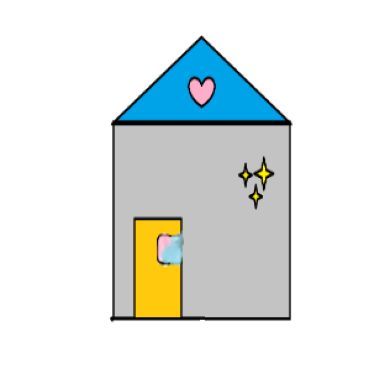

In [79]:
# Write your code here to display img_array
print(img_array.shape)
plt.imshow(img_array)
plt.axis("off")
plt.show()

## Image Cropping

### Student Practice
Crop the **center 200x200 region** of your image (not a random corner — think about how to calculate the center offset from `img_array.shape`), store it in a variable called `crop`, and display it.


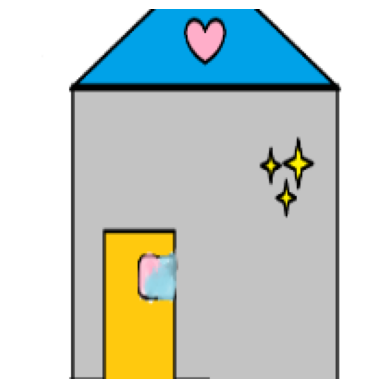

In [80]:
# Write your cropping code here
h, w = img_array.shape[:2]

start_row = (h - 200) // 2
start_col = (w - 200) // 2

crop = img_array[start_row:start_row + 200,
                 start_col:start_col + 200]

plt.imshow(crop)
plt.axis("off")
plt.show()

### Quick demo: showing multiple images side by side

You'll want to display more than one image at once in the tasks below (e.g. two flipped versions, or three RGB channels). `plt.subplots()` lets you do this in a grid. Study this small example, then reuse the pattern.


(np.float64(-0.5), np.float64(299.5), np.float64(299.5), np.float64(-0.5))

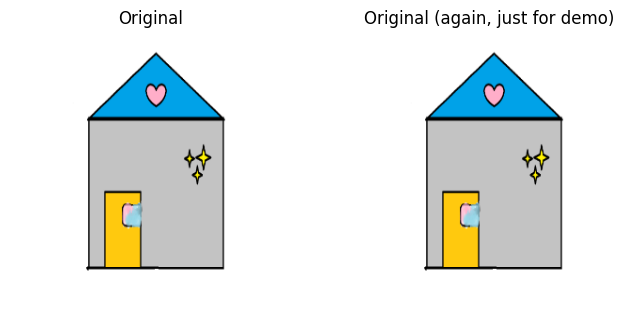

In [82]:
# Demo: showing 2 plots side by side using plt.subplots
fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_array)
axes[1].set_title("Original (again, just for demo)")
axes[1].axis("off")

plt.show()


## Image Flipping

### Student Practice
Produce and display both a vertical flip and a horizontal flip of your image using slicing (`[::-1]`), without using any built-in flip function.


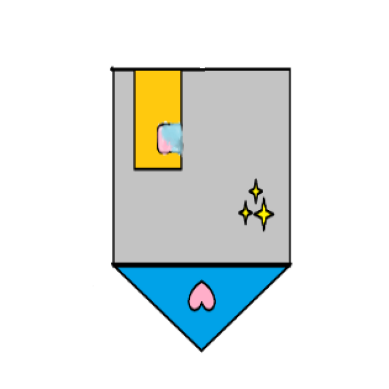

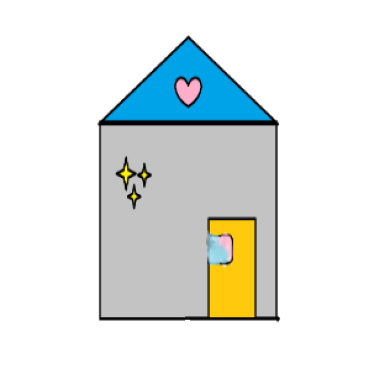

In [8]:
# Write your flipping code here
vertical_flip = img_array[::-1, :, :]

horizontal_flip = img_array[:, ::-1, :]

plt.imshow(vertical_flip)
plt.axis("off")
plt.show()

plt.imshow(horizontal_flip)
plt.axis("off")
plt.show()

## RGB Channel Analysis

RGB channels:

- 0 - Red
- 1 - Green
- 2 - Blue

### Student Practice
Extract the red, green, and blue channels separately, and display each one using `plt.imshow(channel, cmap="gray")` so you can see which areas of the image are strongest in each color.


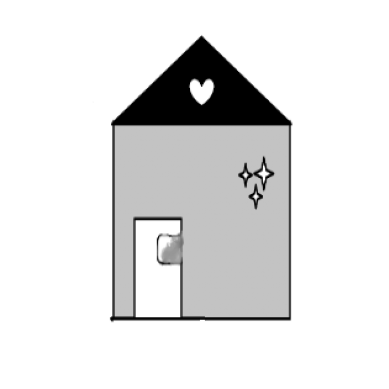

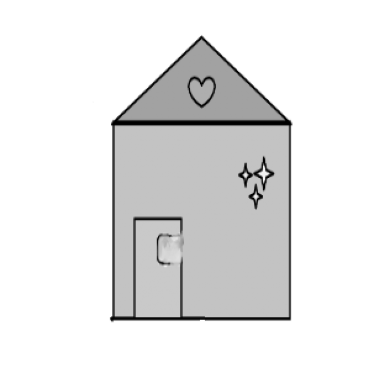

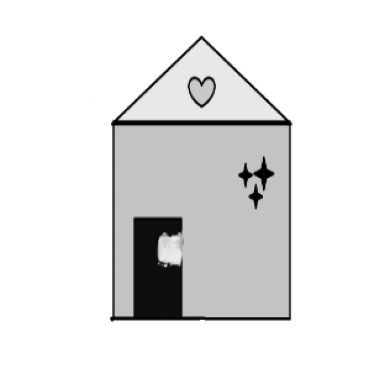

In [87]:
# Write your RGB channel code here
red = img_array[:, :, 0]
green = img_array[:, :, 1]
blue = img_array[:, :, 2]

plt.imshow(red, cmap="gray")
plt.axis("off")
plt.show()

plt.imshow(green, cmap="gray")
plt.axis("off")
plt.show()

plt.imshow(blue, cmap="gray")
plt.axis("off")
plt.show()

## Brightness Analysis

### Student Practice
Calculate the average brightness of your image using `np.mean()`. Then calculate the average brightness of just the red channel, just the green channel, and just the blue channel. Which channel is brightest? Write your answer below the code.


In [88]:
# Write your brightness code here
average_brightness = np.mean(img_array)

red = img_array[:, :, 0]
green = img_array[:, :, 1]
blue = img_array[:, :, 2]

red_brightness = np.mean(red)
green_brightness = np.mean(green)
blue_brightness = np.mean(blue)

print("Average image brightness:", average_brightness)
print("Red channel brightness:", red_brightness)
print("Green channel brightness:", green_brightness)
print("Blue channel brightness:", blue_brightness)

channel_brightness = {
    "Red": red_brightness,
    "Green": green_brightness,
    "Blue": blue_brightness
}

brightest = max(channel_brightness, key=channel_brightness.get)

print("Brightest channel:", brightest)

Average image brightness: 233.9185222222222
Red channel brightness: 223.68413333333334
Green channel brightness: 229.43476666666666
Blue channel brightness: 227.5551888888889
Brightest channel: Green


*Your answer:*


## Thresholding

Convert the image into pure black-and-white using `np.where()`.

### Student Practice
1. Convert the image to grayscale by averaging the 3 channels (`axis=2`).
2. Use `np.where(gray > 128, 255, 0)` to create a binary (black/white) version.
3. Display the result.
4. Try a different threshold (e.g. 100 or 180) and observe how it changes the result.


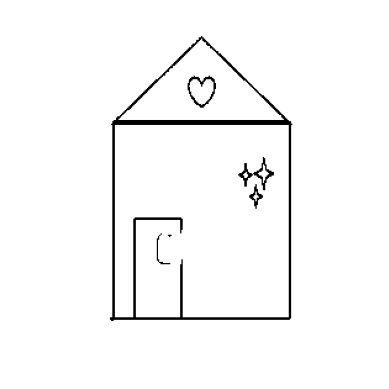

In [13]:
# Write your thresholding code here
gray = np.mean(img_array, axis=2)
binary = np.where(gray > 128, 255, 0)
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

# Mini Project: Image Analyzer

Write a single program (you can reuse code from above) that prints/displays all of the following for your uploaded image, in order:

1. Image height, width, and number of channels
2. Average brightness (overall, and per channel)
3. The cropped center region
4. Both flipped versions (vertical and horizontal)
5. All 3 RGB channels shown separately
6. The thresholded (black/white) version

### Self-check before you submit
- [ ] I wrote the code myself rather than only uncommenting given code
- [ ] I can explain what every line does, not just that it runs
- [ ] My image display uses `plt.axis("off")` and looks correct
- [ ] I answered all reflection questions in my own words

## Reflection Questions

1. Why is NumPy faster than Python lists? (Refer back to your Part 1 answer — refine it if needed.)

2. Explain broadcasting with an example of your own.

3. What does image shape `(512,512,3)` represent?

4. Why should we avoid printing complete image arrays?

5. Explain RGB channels.

6. Where might you use this exact image-array workflow in a real machine learning project (e.g. what comes right before feeding an image into a CNN)?


1. Image Information
Height: 300
Width: 300
Number of channels: 4

2. Brightness Analysis
Overall average brightness: 233.9185222222222
Red channel brightness: 223.68413333333334
Green channel brightness: 229.43476666666666
Blue channel brightness: 227.5551888888889
Brightest channel: Green

3. Center 200x200 Crop


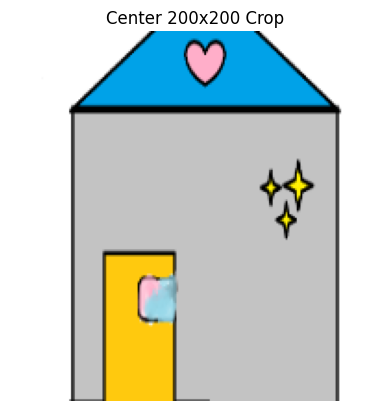


4. Flipped Images


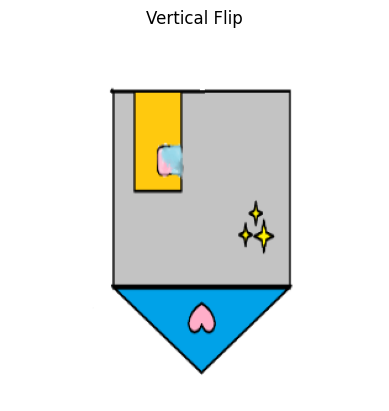

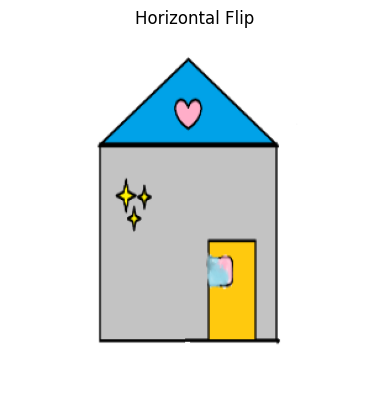


5. RGB Channels


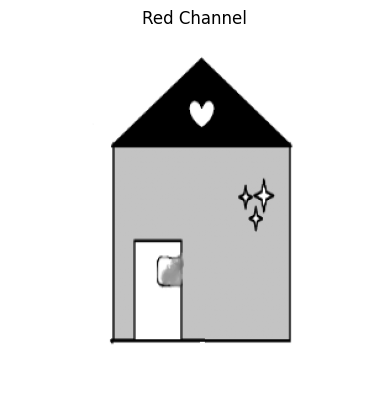

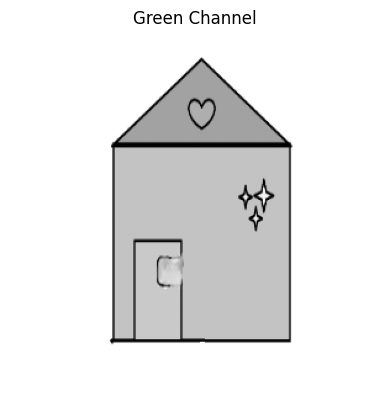

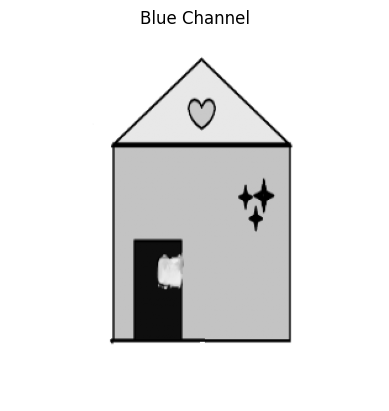


6. Thresholded Image


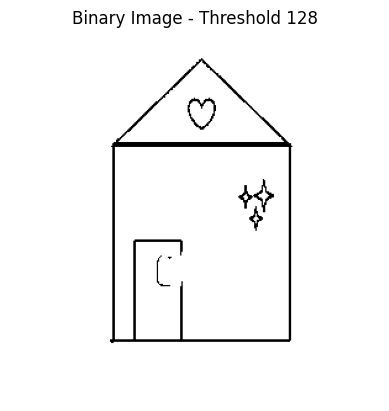

In [14]:
img = Image.open("1lakhrupeespainting.png")
img_array = np.array(img)

height, width = img_array.shape[:2]
channels = img_array.shape[2] if img_array.ndim == 3 else 1

print("1. Image Information")
print("Height:", height)
print("Width:", width)
print("Number of channels:", channels)

red = img_array[:, :, 0]
green = img_array[:, :, 1]
blue = img_array[:, :, 2]

average_brightness = np.mean(img_array)
red_brightness = np.mean(red)
green_brightness = np.mean(green)
blue_brightness = np.mean(blue)

print("\n2. Brightness Analysis")
print("Overall average brightness:", average_brightness)
print("Red channel brightness:", red_brightness)
print("Green channel brightness:", green_brightness)
print("Blue channel brightness:", blue_brightness)

if red_brightness > green_brightness and red_brightness > blue_brightness:
    print("Brightest channel: Red")
elif green_brightness > red_brightness and green_brightness > blue_brightness:
    print("Brightest channel: Green")
else:
    print("Brightest channel: Blue")

start_row = (height - 200) // 2
start_col = (width - 200) // 2

crop = img_array[
    start_row:start_row + 200,
    start_col:start_col + 200
]

print("\n3. Center 200x200 Crop")

plt.imshow(crop)
plt.title("Center 200x200 Crop")
plt.axis("off")
plt.show()

vertical_flip = img_array[::-1, :, :]
horizontal_flip = img_array[:, ::-1, :]

print("\n4. Flipped Images")

plt.imshow(vertical_flip)
plt.title("Vertical Flip")
plt.axis("off")
plt.show()

plt.imshow(horizontal_flip)
plt.title("Horizontal Flip")
plt.axis("off")
plt.show()

print("\n5. RGB Channels")

plt.imshow(red, cmap="gray")
plt.title("Red Channel")
plt.axis("off")
plt.show()

plt.imshow(green, cmap="gray")
plt.title("Green Channel")
plt.axis("off")
plt.show()

plt.imshow(blue, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")
plt.show()

gray = np.mean(img_array, axis=2)

binary = np.where(gray > 128, 255, 0)

print("\n6. Thresholded Image")

plt.imshow(binary, cmap="gray")
plt.title("Binary Image - Threshold 128")
plt.axis("off")
plt.show()

1. NumPy is faster than Python lists because NumPy stores data in a more efficient way and performs operations on many elements at once
2. Broadcasting means NumPy can use a smaller value or array with a bigger array by automatically applying it to the required elements
3. The shape (512,512,3) means the image has 512 pixels in height, 512 pixels in width, and 3 color channels.
4. We should avoid printing the complete image array because an image contains thousands or millions of pixel values.
5. RGB stands for Red, Green, and Blue. Every pixel in a color image contains three values representing the intensity of these three colors.
6. This workflow can be used during image preprocessing before giving an image to a CNN.

# Part 15: Text Analysis Using NumPy (NLP Track)

## Why this matters for ML/NLP

Before any NLP model (sentiment classifier, spam detector, chatbot) can process text, the text must be converted into numbers — this is called **vectorization**. NumPy arrays are the underlying data structure for almost every text representation: word counts, one-hot vectors, TF-IDF vectors, and even word embeddings are all just NumPy (or NumPy-like) arrays.

In this section, you'll build a small text analysis pipeline entirely with NumPy — no external NLP libraries — so you understand what's actually happening under the hood before you use libraries like `scikit-learn` or `nltk` later in the course.


## Step 1: From Text to Tokens

The first step in any NLP pipeline is **tokenization** — splitting text into individual words.

### Demonstration


In [15]:
sentence = "NumPy makes numerical computing fast and NumPy makes arrays powerful"

# Basic tokenization: lowercase + split on spaces
tokens = sentence.lower().split()
print(tokens)


['numpy', 'makes', 'numerical', 'computing', 'fast', 'and', 'numpy', 'makes', 'arrays', 'powerful']


### Student Practice

Tokenize this sentence the same way: `"Data Science and Machine Learning use NumPy arrays every single day"`. Store the result in a variable called `tokens2`.


In [16]:
# Write your answer here
sentence2 = "Data Science and Machine Learning use NumPy arrays every single day"

tokens2 = sentence2.lower().split()

print(tokens2)

['data', 'science', 'and', 'machine', 'learning', 'use', 'numpy', 'arrays', 'every', 'single', 'day']


## Step 2: Building a Vocabulary

A **vocabulary** is the set of all unique words across your text(s). We'll use `np.unique()` — the same function idea you used earlier for arrays of numbers, now applied to an array of words.


In [17]:
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
print("Vocabulary:", vocabulary)
print("Vocabulary size:", len(vocabulary))


Vocabulary: ['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
Vocabulary size: 8


### Student Practice

Build the vocabulary for `tokens2` from Step 1. How many unique words does it contain?


In [18]:
# Write your answer here
tokens2_array = np.array(tokens2)
vocabulary2 = np.unique(tokens2_array)
print("Vocabulary:", vocabulary2)
print("Vocabulary size:", len(vocabulary2))

Vocabulary: ['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
Vocabulary size: 11


## Step 3: Word Frequency Vector (Bag-of-Words)

A **bag-of-words** vector represents a sentence as an array of word counts, one count per vocabulary word — this ignores word order but captures *what* words appear and *how often*.

### Demonstration: build a word-count vector by hand using NumPy


In [19]:
def bag_of_words_vector(tokens, vocabulary):
    # For each word in the vocabulary, count how many times it appears in tokens
    vector = np.array([np.sum(np.array(tokens) == word) for word in vocabulary])
    return vector

vec = bag_of_words_vector(tokens, vocabulary)
print(vocabulary)
print(vec)


['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
[1 1 1 1 2 1 2 1]


### Student Practice — predict then check

Before running, predict: which word(s) will have a count of 2 in the vector above? (Hint: look back at the original sentence — which word repeats?)

*Your prediction:* The words `numpy` and `makes` each appear 2 times.So these both words have count 2

Now build the bag-of-words vector for `tokens2` using its own vocabulary, and check your prediction concept applies the same way.


In [20]:
# Write your answer here
vec2 = bag_of_words_vector(tokens2, vocabulary2)

print(vocabulary2)
print(vec2)

['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
[1 1 1 1 1 1 1 1 1 1 1]


## Step 4: Comparing Two Sentences (Cosine Similarity)

Once text is turned into number vectors, we can measure how *similar* two sentences are using **cosine similarity** — a formula you'll see constantly in NLP and recommendation systems:

$$\text{cosine similarity} = \frac{A \cdot B}{\|A\| \times \|B\|}$$

This measures the angle between two vectors, not their length — so it works even if one sentence is longer than another.

### Demonstration


In [21]:
sentence_a = "machine learning uses numpy arrays"
sentence_b = "deep learning also uses numpy arrays heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()

# Build a shared vocabulary from both sentences combined
combined_vocab = np.unique(np.array(tokens_a + tokens_b))

vec_a = bag_of_words_vector(tokens_a, combined_vocab)
vec_b = bag_of_words_vector(tokens_b, combined_vocab)

print("Vector A:", vec_a)
print("Vector B:", vec_b)

# Cosine similarity using NumPy dot product and norm
cosine_sim = np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
print("Cosine similarity:", cosine_sim)


Vector A: [0 1 0 0 1 1 1 1]
Vector B: [1 1 1 1 1 0 1 1]
Cosine similarity: 0.6761234037828131


### Student Practice

Pick two sentences of your own (write them below) — one pair that should be *similar* in meaning/topic, and one pair that should be *very different*. Compute the cosine similarity for both pairs and confirm your intuition matches the numbers.


In [22]:
# Write your answer here
sentence_1 = "machine learning is useful for data analysis"
sentence_2 = "machine learning helps with data processing"

tokens_1 = sentence_1.lower().split()
tokens_2 = sentence_2.lower().split()

vocab_similar = np.unique(np.array(tokens_1 + tokens_2))

vec_1 = bag_of_words_vector(tokens_1, vocab_similar)
vec_2 = bag_of_words_vector(tokens_2, vocab_similar)

cosine_similar = np.dot(vec_1, vec_2) / (
    np.linalg.norm(vec_1) * np.linalg.norm(vec_2)
)

print("Similar pair:")
print("Vector 1:", vec_1)
print("Vector 2:", vec_2)
print("Cosine similarity:", cosine_similar)


# Very different sentences
sentence_3 = "the football team won the match"
sentence_4 = "chocolate cake tastes sweet and delicious"

tokens_3 = sentence_3.lower().split()
tokens_4 = sentence_4.lower().split()

vocab_different = np.unique(np.array(tokens_3 + tokens_4))

vec_3 = bag_of_words_vector(tokens_3, vocab_different)
vec_4 = bag_of_words_vector(tokens_4, vocab_different)

cosine_different = np.dot(vec_3, vec_4) / (
    np.linalg.norm(vec_3) * np.linalg.norm(vec_4)
)

print("\nVery different pair:")
print("Vector 3:", vec_3)
print("Vector 4:", vec_4)
print("Cosine similarity:", cosine_different)

Similar pair:
Vector 1: [1 1 1 0 1 1 1 0 1 0]
Vector 2: [0 1 0 1 0 1 1 1 0 1]
Cosine similarity: 0.4629100498862757

Very different pair:
Vector 3: [0 0 0 0 1 1 0 0 1 2 1]
Vector 4: [1 1 1 1 0 0 1 1 0 0 0]
Cosine similarity: 0.0


**Reflection:** In your own words, why does cosine similarity give a value close to 1 for similar sentences and close to 0 for unrelated sentences? What would a `cosine similarity` of exactly 1 mean about two vectors?

*Your answer:* Cosine similarity compares the direction of two vectors not just their size.

For similar sentences, their Bag-of-Words vectors have many words in common, so the vectors point in a similar direction. Therefore, their cosine similarity is closer to 1.

For unrelated sentences, they have few or no common words, so their vectors point in different directions. Their cosine similarity is therefore closer to 0.


## Step 5: Most Frequent Words

### Student Practice

Take any paragraph of your choice (3-4 sentences, write it below as a string). Then:
1. Tokenize it.
2. Build its vocabulary and word-count vector (reuse `bag_of_words_vector`).
3. Use NumPy to find and print the **top 3 most frequent words** (hint: look at sorting — `np.argsort()` sorts indices by value, and slicing with `[::-1]` reverses order).


In [23]:
# Write your answer here
paragraph = """
Machine learning is a useful technology.
Machine learning helps computers learn from data.
Data helps machine learning models make better predictions.
Learning from data is important in machine learning.
"""
tokens = paragraph.lower().split()

print("Tokens:")
print(tokens)

tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)

vec = bag_of_words_vector(tokens, vocabulary)

print("\nVocabulary:")
print(vocabulary)

print("\nWord-count vector:")
print(vec)

sorted_indices = np.argsort(vec)[::-1]

top_3_indices = sorted_indices[:3]

print("\nTop 3 most frequent words:")

for i in top_3_indices:
    print(vocabulary[i], ":", vec[i])

Tokens:
['machine', 'learning', 'is', 'a', 'useful', 'technology.', 'machine', 'learning', 'helps', 'computers', 'learn', 'from', 'data.', 'data', 'helps', 'machine', 'learning', 'models', 'make', 'better', 'predictions.', 'learning', 'from', 'data', 'is', 'important', 'in', 'machine', 'learning.']

Vocabulary:
['a' 'better' 'computers' 'data' 'data.' 'from' 'helps' 'important' 'in'
 'is' 'learn' 'learning' 'learning.' 'machine' 'make' 'models'
 'predictions.' 'technology.' 'useful']

Word-count vector:
[1 1 1 2 1 2 2 1 1 2 1 4 1 4 1 1 1 1 1]

Top 3 most frequent words:
machine : 4
learning : 4
is : 2


# Mini Project: Simple Text Similarity Checker (NLP Track)

Build a small program that:

1. Takes **three** short sentences of your choice (write them as strings).
2. Tokenizes all three and builds one shared vocabulary across all of them.
3. Converts each sentence into a bag-of-words vector using that shared vocabulary.
4. Computes cosine similarity between every pair of sentences (3 pairs total: 1-2, 1-3, 2-3).
5. Prints which two sentences are the **most similar** to each other, based on the highest cosine similarity score.

### Self-check before you submit
- [ ] I wrote my own three sentences (not copied from the notebook)
- [ ] I can explain what a bag-of-words vector represents, in my own words
- [ ] I can explain why cosine similarity works even when sentences are different lengths
- [ ] My program correctly identifies and prints the most similar pair

## Reflection Questions (NLP Track)

1. Why do we need to convert text into numbers before a machine learning model can use it?

2. What information does a bag-of-words vector *lose* about the original sentence? (Hint: think about what `split()` and counting alone doesn't capture.)

3. Why might cosine similarity be a better similarity measure than simply comparing raw word-count differences?

4. Name one real-world application that likely uses something like this text-vectorization + similarity approach (e.g. search engines, plagiarism checkers, recommendation systems — pick one and explain briefly).


In [24]:
sentence_1 = "machine learning helps analyze data"
sentence_2 = "machine learning is useful for data analysis"
sentence_3 = "football players practice every day"

tokens_1 = sentence_1.lower().split()
tokens_2 = sentence_2.lower().split()
tokens_3 = sentence_3.lower().split()

combined_tokens = tokens_1 + tokens_2 + tokens_3
shared_vocabulary = np.unique(np.array(combined_tokens))

print("Shared Vocabulary:")
print(shared_vocabulary)

vec_1 = bag_of_words_vector(tokens_1, shared_vocabulary)
vec_2 = bag_of_words_vector(tokens_2, shared_vocabulary)
vec_3 = bag_of_words_vector(tokens_3, shared_vocabulary)

print("\nVector 1:", vec_1)
print("Vector 2:", vec_2)
print("Vector 3:", vec_3)


def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

sim_12 = cosine_similarity(vec_1, vec_2)
sim_13 = cosine_similarity(vec_1, vec_3)
sim_23 = cosine_similarity(vec_2, vec_3)

print("\nCosine Similarities:")
print("Sentence 1 - Sentence 2:", sim_12)
print("Sentence 1 - Sentence 3:", sim_13)
print("Sentence 2 - Sentence 3:", sim_23)

similarities = {
    "Sentence 1 and Sentence 2": sim_12,
    "Sentence 1 and Sentence 3": sim_13,
    "Sentence 2 and Sentence 3": sim_23
}

most_similar_pair = max(similarities, key=similarities.get)

print("\nMost similar pair:", most_similar_pair)
print("Similarity score:", similarities[most_similar_pair])

Shared Vocabulary:
['analysis' 'analyze' 'data' 'day' 'every' 'football' 'for' 'helps' 'is'
 'learning' 'machine' 'players' 'practice' 'useful']

Vector 1: [0 1 1 0 0 0 0 1 0 1 1 0 0 0]
Vector 2: [1 0 1 0 0 0 1 0 1 1 1 0 0 1]
Vector 3: [0 0 0 1 1 1 0 0 0 0 0 1 1 0]

Cosine Similarities:
Sentence 1 - Sentence 2: 0.5070925528371099
Sentence 1 - Sentence 3: 0.0
Sentence 2 - Sentence 3: 0.0

Most similar pair: Sentence 1 and Sentence 2
Similarity score: 0.5070925528371099


1. Machine learning models work with numerical values and mathematical operations.And also computer cannot uderstand the meaning of words as text
2. A Bag-of-Words vector loses the order of words in the sentence.
3. Cosine similarity compares the direction of the vectors, rather than just their numerical differences.
4. One application is search engines. When we search for something, the search query and documents can be converted into numerical vectors. Cosine similarity or similar techniques can then help determine which documents are most related to the query.